<a href="https://colab.research.google.com/github/Zeldian-Soul/AI-ML-lab-/blob/main/Searching_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BFS Traversal starting from 'A': ['A', 'B', 'C', 'D', 'E', 'F']


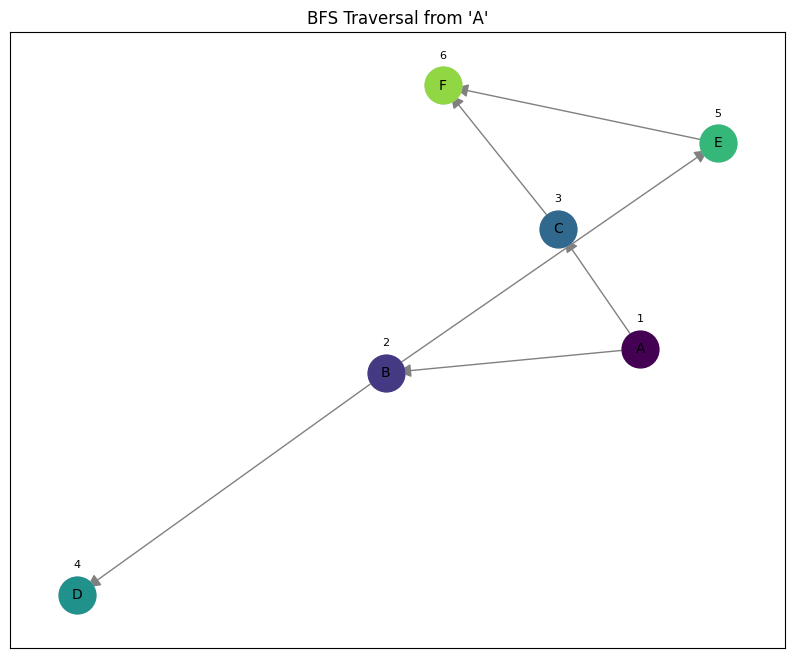

BFS Traversal starting from 0: [0, 1, 2, 3, 4]


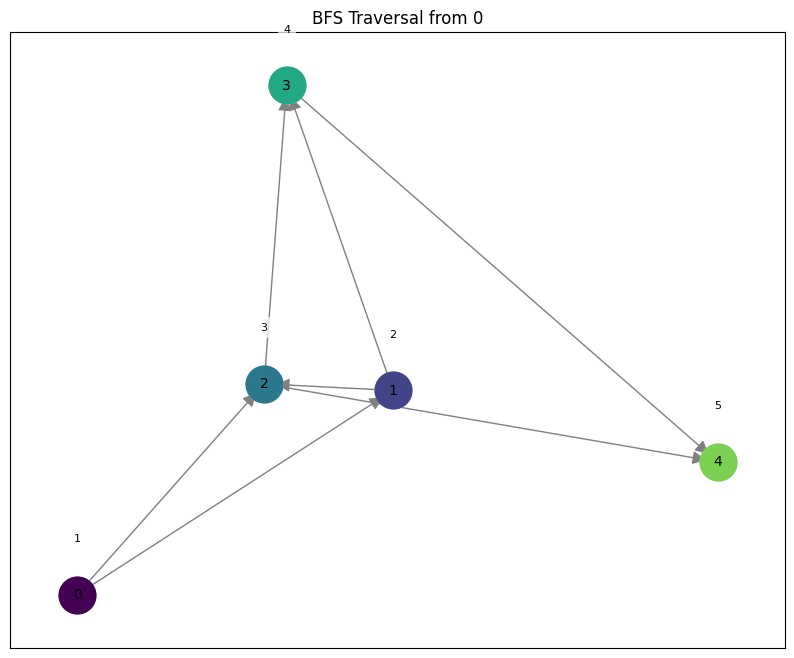

In [3]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

def bfs(graph, start_node):
    visited = set()
    queue = deque([start_node])
    visited.add(start_node)

    traversal_order = []

    while queue:
        current_node = queue.popleft()
        traversal_order.append(current_node)

        for neighbor in graph[current_node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return traversal_order

def visualize_bfs(graph, traversal_order, title="BFS Traversal"):
    G = nx.DiGraph() # Use DiGraph to show direction of edges

    # Add nodes and edges
    for node, neighbors in graph.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
            if neighbor not in G: # Ensure all neighbors are added as nodes
                G.add_node(neighbor)

    # Define positions for nodes for consistent layout
    pos = nx.spring_layout(G, seed=42) # For reproducible layout

    plt.figure(figsize=(10, 8))
    plt.title(title)

    # Draw initial graph (all nodes and edges)
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=700)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

    # Highlight BFS path
    for i, node in enumerate(traversal_order):
        # Nodes are colored sequentially, making the path visible
        node_color = plt.cm.viridis(i / len(traversal_order))
        nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color=[node_color], node_size=700)
        # Optionally, label the order of traversal
        plt.text(pos[node][0], pos[node][1] + 0.1, str(i+1),
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=8, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.show()


# Example Graph 1 (Adjacency List Representation)
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

# Perform BFS starting from node 'A'
bfs_result = bfs(graph, 'A')
print(f"BFS Traversal starting from 'A': {bfs_result}")
# Visualize the first BFS traversal
visualize_bfs(graph, bfs_result, "BFS Traversal from 'A'")


# Example Graph 2 (Adjacency List Representation)
graph2 = {
    0: [1, 2],
    1: [2, 3],
    2: [3, 4],
    3: [4],
    4: []
}

# Perform BFS starting from node 0
bfs_result2 = bfs(graph2, 0)
print(f"BFS Traversal starting from 0: {bfs_result2}")
# Visualize the second BFS traversal
visualize_bfs(graph2, bfs_result2, "BFS Traversal from 0")

## Depth-First Search (DFS) Implementation and Visualization

Now, let's implement and visualize the Depth-First Search (DFS) algorithm for the same example graphs.

In [4]:
def dfs(graph, start_node):
    visited = set()
    stack = [start_node]  # DFS uses a stack
    traversal_order = []

    while stack:
        current_node = stack.pop() # Pop from the end (LIFO)

        if current_node not in visited:
            visited.add(current_node)
            traversal_order.append(current_node)

            # Add neighbors to the stack. Reverse order to process in typical left-to-right fashion
            # (assuming adjacency list is ordered, this makes sense for deterministic output)
            for neighbor in reversed(graph.get(current_node, [])):
                if neighbor not in visited:
                    stack.append(neighbor)
    return traversal_order

def visualize_dfs(graph, traversal_order, title="DFS Traversal"):
    G = nx.DiGraph() # Use DiGraph to show direction of edges

    # Add nodes and edges
    for node, neighbors in graph.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
            if neighbor not in G: # Ensure all neighbors are added as nodes
                G.add_node(neighbor)

    # Define positions for nodes for consistent layout
    pos = nx.spring_layout(G, seed=42) # For reproducible layout

    plt.figure(figsize=(10, 8))
    plt.title(title)

    # Draw initial graph (all nodes and edges)
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=700)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

    # Highlight DFS path
    for i, node in enumerate(traversal_order):
        # Nodes are colored sequentially, making the path visible
        node_color = plt.cm.plasma(i / len(traversal_order)) # Using 'plasma' colormap for DFS
        nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color=[node_color], node_size=700)
        # Optionally, label the order of traversal
        plt.text(pos[node][0], pos[node][1] + 0.1, str(i+1),
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=8, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.show()

DFS Traversal starting from 'A': ['A', 'B', 'D', 'E', 'F', 'C']


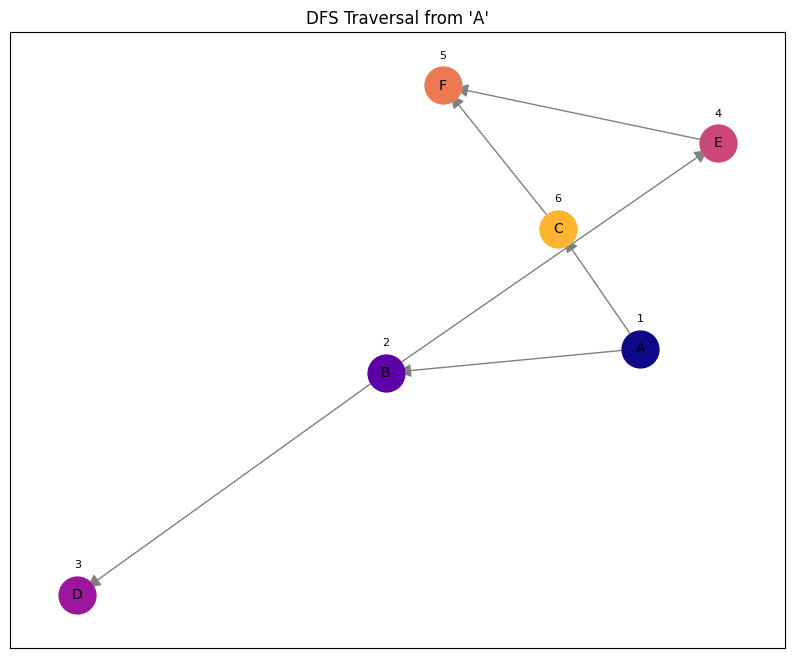

DFS Traversal starting from 0: [0, 1, 2, 3, 4]


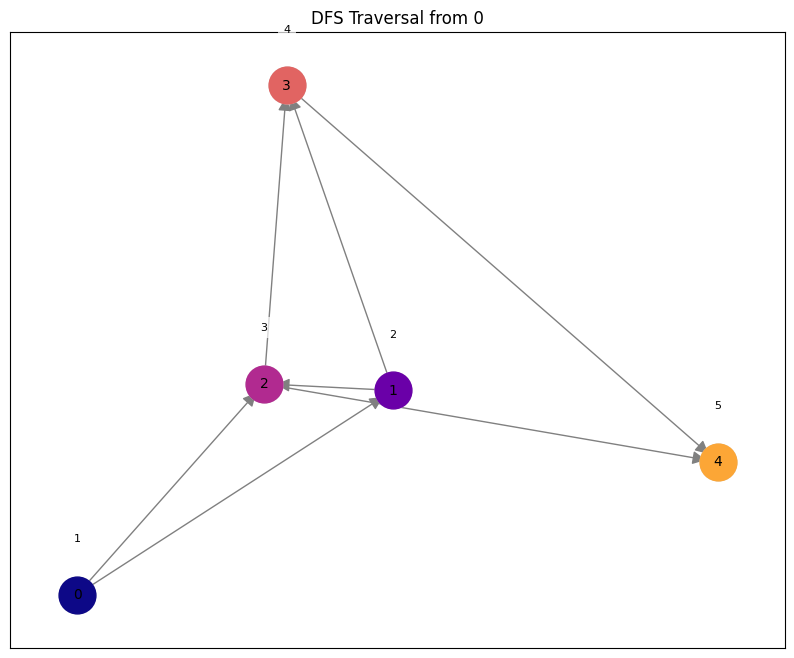

In [5]:
# Perform DFS starting from node 'A' for the first graph
dfs_result = dfs(graph, 'A')
print(f"DFS Traversal starting from 'A': {dfs_result}")

# Visualize the DFS traversal for the first graph
visualize_dfs(graph, dfs_result, "DFS Traversal from 'A'")

# Perform DFS starting from node 0 for the second graph
dfs_result2 = dfs(graph2, 0)
print(f"DFS Traversal starting from 0: {dfs_result2}")

# Visualize the DFS traversal for the second graph
visualize_dfs(graph2, dfs_result2, "DFS Traversal from 0")

**Greedy Best First Search Algorithm**

Greedy Best-First Search from 'A' to 'F': ['A', 'C', 'F']


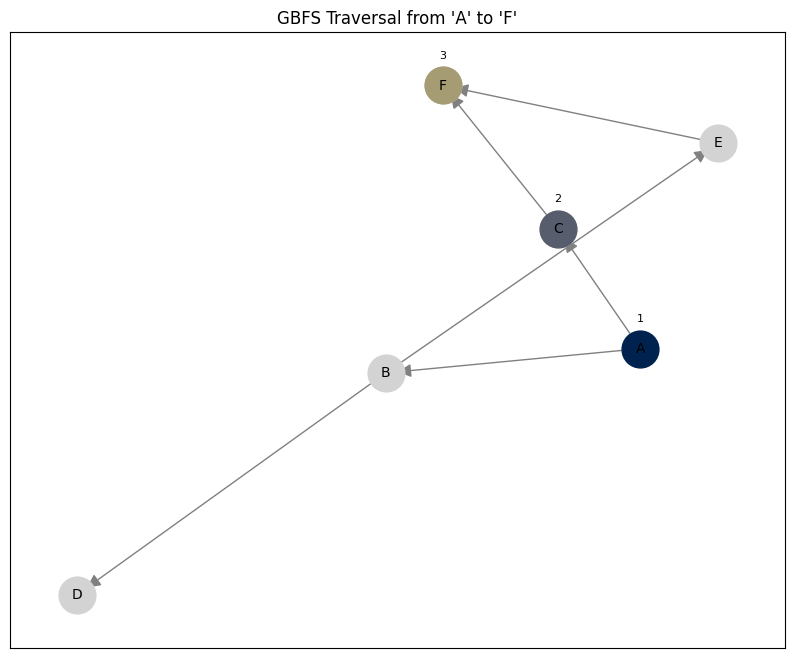

Greedy Best-First Search from 0 to 4: [0, 2, 4]


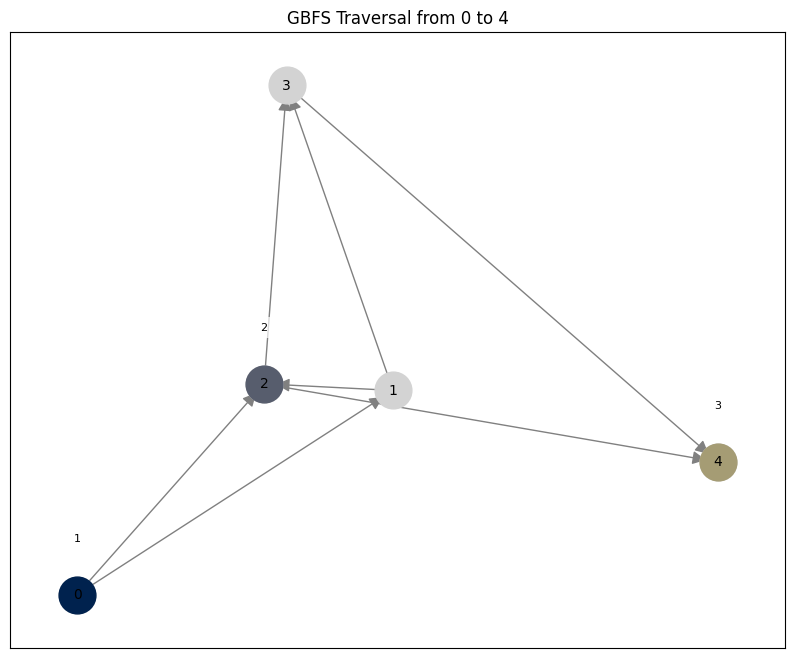

In [7]:
import heapq # Required for priority queue
import networkx as nx
import matplotlib.pyplot as plt

def greedy_best_first_search(graph, start_node, goal_node, heuristic_values):
    visited = set()
    # Priority queue stores tuples: (heuristic_value, node)
    priority_queue = [(heuristic_values[start_node], start_node)]
    traversal_order = []

    while priority_queue:
        # Pop the node with the lowest heuristic value
        current_h_value, current_node = heapq.heappop(priority_queue)

        if current_node not in visited:
            visited.add(current_node)
            traversal_order.append(current_node)

            if current_node == goal_node:
                return traversal_order # Path found

            for neighbor in graph.get(current_node, []):
                if neighbor not in visited:
                    # Push neighbor with its heuristic value
                    heapq.heappush(priority_queue, (heuristic_values.get(neighbor, float('inf')), neighbor))

    return traversal_order # Goal not reachable

def visualize_search(graph, traversal_order, title="Graph Search Traversal"):
    G = nx.DiGraph() # Use DiGraph to show direction of edges

    # Add nodes and edges
    for node, neighbors in graph.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
            if neighbor not in G: # Ensure all neighbors are added as nodes
                G.add_node(neighbor)

    # Define positions for nodes for consistent layout
    pos = nx.spring_layout(G, seed=42) # For reproducible layout

    plt.figure(figsize=(10, 8))
    plt.title(title)

    # Draw initial graph (all nodes and edges)
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=700)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

    # Highlight search path
    for i, node in enumerate(traversal_order):
        # Nodes are colored sequentially, making the path visible
        node_color = plt.cm.cividis(i / len(traversal_order)) # Using 'cividis' colormap for GBFS
        nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color=[node_color], node_size=700)
        # Optionally, label the order of traversal
        plt.text(pos[node][0], pos[node][1] + 0.1, str(i+1),
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=8, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.show()


# --- Example 1: Graph with characters ---
# Heuristic values for graph1 (goal 'F')
# These are arbitrary values for demonstration, estimating distance to 'F'
heuristic_graph1 = {
    'A': 6, 'B': 4, 'C': 3,
    'D': 5, 'E': 1, 'F': 0
}
start_node_1 = 'A'
goal_node_1 = 'F'

gbfs_result1 = greedy_best_first_search(graph, start_node_1, goal_node_1, heuristic_graph1)
print(f"Greedy Best-First Search from '{start_node_1}' to '{goal_node_1}': {gbfs_result1}")
visualize_search(graph, gbfs_result1, f"GBFS Traversal from '{start_node_1}' to '{goal_node_1}'")


# --- Example 2: Graph with numbers ---
# Heuristic values for graph2 (goal 4)
# These are arbitrary values for demonstration, estimating distance to 4
heuristic_graph2 = {
    0: 4, 1: 2, 2: 1,
    3: 1, 4: 0
}
start_node_2 = 0
goal_node_2 = 4

gbfs_result2 = greedy_best_first_search(graph2, start_node_2, goal_node_2, heuristic_graph2)
print(f"Greedy Best-First Search from {start_node_2} to {goal_node_2}: {gbfs_result2}")
visualize_search(graph2, gbfs_result2, f"GBFS Traversal from {start_node_2} to {goal_node_2}")